# Sigma-clip + Position-Angle fitting demo

This notebook demonstrates the V0.6 palfitology workflow end-to-end:

1. **One galaxy** — build 12-band synthetic cutouts, sigma-clip on rSDSS,
   apply the mask to every band, then fit the position angle on the clipped
   images.  Show the 12-band ellipse-overlay mosaic.
2. **Multiple galaxies** — repeat for a small synthetic catalog of three
   galaxies with different orientations, and produce a `summarize-cutouts`
   style raw|clipped diagnostic per object.
3. **RGB composite** — build a colour image from the iSDSS / rSDSS / gSDSS
   bands (the J-PLUS bands closest to true red / green / blue).

This notebook uses **synthetic** galaxies so it can be run with no external
data dependencies.  Once you've eyeballed the workflow, run the same
commands as a CLI on your real `images/` folder:

```bash
palfitology make-cutouts        --detect-sigma 3.0 --apply-bands all
palfitology fit-pa              --use-clipped-cutouts
palfitology summarize-cutouts   # per-object raw|clipped diagnostic PNGs
```

## 1. Setup

In [1]:
# Inline backend so all matplotlib figures appear right under the cells.
%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import os
import sys
import shutil
from pathlib import Path

# Make BLAS / OpenMP single-threaded BEFORE numpy is imported so the per-band
# parallelism in fit_catalog doesn't oversubscribe the kernel.
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
            "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(var, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize, ZScaleInterval

# Editable-install of the package; assume the notebook lives in
# <repo>/notebooks/.  Adjust sys.path so the kernel finds palfitology even
# without `pip install -e .`.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

from palfitology import ALL_BANDS, fit_catalog
from palfitology.cutouts import (
    make_cutouts_for_catalog,
    summarize_object_clipped_cutouts,
)
from palfitology.detect import detect_source, make_clipped_cutout
from palfitology.fit import fit_pa_with_fallbacks
from palfitology.images import locate_band_fits

print("palfitology imports ok; ALL_BANDS =", ALL_BANDS)

palfitology imports ok; ALL_BANDS = ['uJAVA', 'J0378', 'J0395', 'J0410', 'J0430', 'gSDSS', 'J0515', 'rSDSS', 'J0660', 'iSDSS', 'J0861', 'zSDSS']


/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Build a synthetic 12-band image set

We render edge-on Gaussian "galaxies" with a per-object PA and a per-band
brightness scale that mimics the J-PLUS bands' relative throughput.  These
land on disk in the same `fits_images_<ra>_<dec>/<band>_cutout.fits` layout
the palfitology pipeline expects.

In [2]:
# Point at your real J-PLUS images instead of building synthetic ones.
DEMO_DIR = Path("/Users/nacharya/Desktop/AntigravityProjects/PALFITology_old").resolve()
images_root = DEMO_DIR / "images"
assert images_root.is_dir(), f"images_root not found: {images_root}"

# Discover the object IDs available on disk (subfolders of images_root that
# contain a fits_images_*/rSDSS_cutout.fits).
all_object_ids = sorted(
    p.name for p in images_root.iterdir()
    if p.is_dir() and any(p.glob("fits_images_*/rSDSS_cutout.fits"))
)
print(f"Found {len(all_object_ids)} objects with an rSDSS cutout.")
print("First 10:", all_object_ids[:10])

Found 48 objects with an rSDSS cutout.
First 10: ['92037-12721', '92452-15306', '92452-9227', '92456-13220', '92456-24792', '92480-13118', '92480-20952', '92755-2558', '92765-10758', '92777-1366']


## 3. One galaxy — sigma-clip on the rSDSS band

Step 1 of the V0.6 workflow: use the rSDSS cutout to derive a sigma-clipped
detection mask, then apply the **same** mask to every other band.  We do
this in-process here so the notebook can plot the mask and the clipped
arrays directly.

In [3]:
# Pick which object to use for the single-galaxy walkthrough.
SINGLE_OBJECT_ID = all_object_ids[0]   # or hardcode a specific id, e.g. "92801-11428"
print(f"Single-object demo uses: {SINGLE_OBJECT_ID}")

# Open the rSDSS cutout for the chosen object.
r_path = locate_band_fits(images_root / SINGLE_OBJECT_ID, "rSDSS")

with fits.open(r_path) as hdul:
    r_data = hdul[0].data.astype(float)

# Sigma-clip detection: returns the clipped array, the binary mask, and the
# DetectionResult dataclass with centroid + moments.
r_clipped, mask, det = make_clipped_cutout(r_data, sigma_threshold=3.0)

print(f"detection status   : {det.status}")
print(f"pixels above 3σ    : {det.npix}")
print(f"centroid (x, y)    : ({det.x0:.2f}, {det.y0:.2f})")
print(f"moment-derived PA  : {det.pa_deg:.2f}°")
print(f"moment-derived eps : {det.eps:.3f}")
print(f"background ± rms   : {det.background:.3g} ± {det.background_rms:.3g}")

Single-object demo uses: 92037-12721
detection status   : ok
pixels above 3σ    : 1007
centroid (x, y)    : (43.88, 43.43)
moment-derived PA  : -3.85°
moment-derived eps : 0.056
background ± rms   : 0.753 ± 0.471


In [4]:
# Visualise raw | mask | clipped, side by side.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
norm = ImageNormalize(r_data, interval=ZScaleInterval(), stretch=AsinhStretch())

axes[0].imshow(r_data, origin="lower", cmap="gray_r", norm=norm)
axes[0].set_title("rSDSS raw")
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].imshow(r_data, origin="lower", cmap="gray_r", norm=norm)
axes[1].contour(mask.astype(int), levels=[0.5], colors=["lime"], linewidths=1.5)
axes[1].plot(det.x0, det.y0, "r+", ms=14, mew=2)
axes[1].set_title(f"Detection mask  (σ=3, npix={det.npix})")
axes[1].set_xticks([]); axes[1].set_yticks([])

cmap_nan = plt.cm.gray_r.copy()
cmap_nan.set_bad("crimson")
axes[2].imshow(r_clipped, origin="lower", cmap=cmap_nan, norm=norm)
axes[2].set_title("rSDSS clipped  (NaN → crimson)")
axes[2].set_xticks([]); axes[2].set_yticks([])

fig.tight_layout()
plt.show()

/var/folders/q7/9pgntf4j4hq0gwzt6zwvy37r0000gp/T/ipykernel_32342/809545757.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. One galaxy — apply the rSDSS mask to all 12 bands and fit PA

We persist the clipped cutouts to disk via `make_cutouts_for_catalog`, then
fit the position angle on each band's clipped image.  Because the isophote
fitter doesn't handle NaN cleanly, we fill the masked region with the
background mean before fitting — that gives photutils a smooth field
outside the source while still suppressing any contaminating neighbours.

This is the recommended workflow until a future palfitology release adds
NaN-aware fitting at the CLI level.

In [6]:
# Build the clipped FITS files in the sibling 'clipped_cutouts_*/' folder.
# Single-object catalog — we don't actually need A_WORLD/B_WORLD/pa_jplus
# because make_cutouts_for_catalog only consumes the 'id' column.
catalog = pd.DataFrame({"id": [SINGLE_OBJECT_ID]})
reports = make_cutouts_for_catalog(
    images_root=images_root,
    catalog=catalog,
    detect_band="rSDSS",
    apply_bands=list(ALL_BANDS),
    sigma_threshold=3.0,
)
print(f"wrote {sum(1 for r in reports if r.status == 'ok')} clipped FITS files")
print("first three:", [r.out_path for r in reports[:3]])

wrote 12 clipped FITS files
first three: ['/Users/nacharya/Desktop/AntigravityProjects/PALFITology_old/images/92037-12721/clipped_cutouts_198.0708_44.8392/uJAVA_cutout.fits', '/Users/nacharya/Desktop/AntigravityProjects/PALFITology_old/images/92037-12721/clipped_cutouts_198.0708_44.8392/J0378_cutout.fits', '/Users/nacharya/Desktop/AntigravityProjects/PALFITology_old/images/92037-12721/clipped_cutouts_198.0708_44.8392/J0395_cutout.fits']


In [7]:
# For each band, load the clipped FITS, fill NaN with the background, fit PA.
# We use keep_best_of=2 here so the notebook finishes quickly in CI; the
# default (8) gives slightly tighter fits but takes ~5x longer.
KEEP_BEST_OF = 2

band_results = []
band_images = {}   # the filled image we actually fitted (for plotting)
band_clipped = {}  # the raw NaN-clipped image (for the mosaic overlay)
band_cands = {}

for band in ALL_BANDS:
    clipped_path = next(
        (images_root / SINGLE_OBJECT_ID).glob(f"clipped_cutouts_*/{band}_cutout.fits")
    )
    with fits.open(clipped_path) as hdul:
        data_nan = hdul[0].data.astype(float)

    # Fill NaN with the rSDSS background so photutils can fit.  We use the
    # detection's background; for real data the background varies per band,
    # so re-estimate per-band if you need higher precision.
    finite = np.isfinite(data_nan)
    bg_band = float(np.nanmedian(data_nan[finite])) if finite.any() else 0.0
    data_filled = np.where(finite, data_nan, bg_band)

    cand, n_tried = fit_pa_with_fallbacks(
        data=data_filled,
        eps_prior=0.7,
        pa_prior=0.0,
        min_sma_abs=3.0,
        min_sma_frac=0.05,
        keep_best_of=KEEP_BEST_OF,
    )
    band_clipped[band] = data_nan
    band_images[band] = data_filled
    band_cands[band] = cand
    band_results.append({
        "band": band,
        "fit_status": "ok" if cand is not None and not cand.weak else (
            "weak" if cand is not None else "imputed"
        ),
        "PA_deg": cand.pa_deg if cand is not None else np.nan,
        "ell":    cand.ell    if cand is not None else np.nan,
        "SMA":    cand.sma    if cand is not None else np.nan,
        "PA_err": cand.pa_err if cand is not None else np.nan,
        "n_tried": n_tried,
    })

results_df = pd.DataFrame(band_results)
results_df

/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:336: RuntimeWarning: divide by zero encountered in scalar divide
  ea = abs(errors[2] / self.grad)
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:337: RuntimeWarning: divide by zero encountered in scalar divide
  eb = abs(errors[1] * (1.0 - eps) / self.grad)
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:340: RuntimeWarning: divide by zero encountered in scalar divide
  self.ellip_err = (abs(2.0 * errors[4] * (1.0 - eps) / self.sma
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:343: RuntimeWarning: divide by zero encountered in scalar divide
  self.pa_err = (abs(2.0 * errors[3] * (1.0 - eps) / self.sma
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:287: RuntimeWarning: divide by zero encountered in scalar divide
  a = up_coeffs[1] / self.

,band,fit_status,PA_deg,ell,SMA,PA_err,n_tried
0,uJAVA,imputed,NaN,NaN,NaN,NaN,114
1,J0378,imputed,NaN,NaN,NaN,NaN,114
2,J0395,imputed,NaN,NaN,NaN,NaN,114
3,J0410,imputed,NaN,NaN,NaN,NaN,114
4,J0430,imputed,NaN,NaN,NaN,NaN,114
5,gSDSS,imputed,NaN,NaN,NaN,NaN,114
6,J0515,imputed,NaN,NaN,NaN,NaN,114
7,rSDSS,imputed,NaN,NaN,NaN,NaN,114
8,J0660,imputed,NaN,NaN,NaN,NaN,114
9,iSDSS,imputed,NaN,NaN,NaN,NaN,114


## 5. One galaxy — 12-band ellipse-overlay mosaic on the clipped images

This is the headline diagnostic: each panel shows the clipped cutout (NaN
in crimson, source in grayscale) with the fitted ellipse overlaid.  The
ellipse should hug the bright source in every band; if any band's ellipse
looks misaligned that's the one to investigate.

In [8]:
from matplotlib.patches import Ellipse as MplEllipse


def _safe_norm(arr):
    """ImageNormalize with eagerly-evaluated ZScale and robust fallbacks."""
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return None
    zmin = zmax = None
    try:
        zmin, zmax = ZScaleInterval().get_limits(arr)
    except Exception:
        pass
    if (zmin is not None and np.isfinite(zmin) and np.isfinite(zmax)
            and zmin < zmax):
        return ImageNormalize(vmin=float(zmin), vmax=float(zmax),
                              stretch=AsinhStretch())
    vmin, vmax = np.percentile(finite, [1, 99])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = float(finite.min())
        vmax = float(finite.max())
        if vmin >= vmax:
            vmax = vmin + max(abs(vmin) * 1e-6, 1e-9)
    return ImageNormalize(vmin=float(vmin), vmax=float(vmax),
                          stretch=AsinhStretch())


def _ellipse_is_valid(cand):
    if cand is None:
        return False
    vals = [cand.pa_deg, cand.sma, cand.ell, cand.x0, cand.y0]
    if not np.all(np.isfinite(vals)):
        return False
    smb = cand.sma * (1.0 - cand.ell)
    return cand.sma > 0 and smb > 0


ncols = 4
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
cmap_nan = plt.cm.gray_r.copy()
cmap_nan.set_bad("crimson")

for i, band in enumerate(ALL_BANDS):
    ax = axes[i // ncols, i % ncols]
    ax.set_autoscale_on(False)

    clipped = band_clipped[band]
    filled  = band_images[band]
    cand    = band_cands[band]

    norm = _safe_norm(filled)
    if norm is None:
        ax.imshow(clipped, origin="lower", cmap=cmap_nan)
    else:
        ax.imshow(clipped, origin="lower", cmap=cmap_nan, norm=norm)

    ny, nx = clipped.shape
    ax.set_xlim(-0.5, nx - 0.5)
    ax.set_ylim(-0.5, ny - 0.5)

    if _ellipse_is_valid(cand):
        smb = cand.sma * (1.0 - cand.ell)
        ax.add_patch(MplEllipse(
            (cand.x0, cand.y0),
            width=2 * cand.sma,
            height=2 * smb,
            angle=cand.pa_deg,
            edgecolor="red" if not cand.weak else "orange",
            facecolor="none",
            lw=1.5,
        ))
        ax.plot(cand.x0, cand.y0, "+", color="cyan", ms=8, mew=1.4)
        title = f"{band}\nPA={cand.pa_deg:.1f}°  ell={cand.ell:.2f}"
    else:
        title = f"{band}\n(no fit)"
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"{SINGLE_OBJECT_ID} — 12-band ellipse overlays on the sigma-clipped cutouts",
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

/var/folders/q7/9pgntf4j4hq0gwzt6zwvy37r0000gp/T/ipykernel_32342/3673013980.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Multiple galaxies — batch sigma-clip + fit

The CLI handles this with `palfitology make-cutouts` + `fit-pa
--use-clipped-cutouts`.  Inside the notebook we drive the same Python API
directly so we can plot results inline.

We render three synthetic galaxies at PA = 0°, 35°, and 75° and check that
the pipeline recovers each.

In [9]:
# Pick the first N objects from disk for the multi-galaxy demo.
N_OBJECTS = 3   # bump to 10, 20, ... when you want a bigger run
multi_object_ids = all_object_ids[:N_OBJECTS]
print(f"Multi-object demo uses: {multi_object_ids}")

multi_catalog = pd.DataFrame({"id": multi_object_ids})

# Re-run make-cutouts for the multi-object set. This will rewrite the
# clipped_cutouts_*/ folder for each object; pass overwrite=False to skip
# objects you've already processed.
reports = make_cutouts_for_catalog(
    images_root=images_root,
    catalog=multi_catalog,
    detect_band="rSDSS",
    apply_bands=list(ALL_BANDS),
    sigma_threshold=3.0,
)
print(f"clipped FITS written: {sum(1 for r in reports if r.status == 'ok')} / {len(reports)}")

Multi-object demo uses: ['92037-12721', '92452-15306', '92452-9227']
clipped FITS written: 36 / 36


In [10]:
# Now fit PA on every (object, band) using the clipped cutouts.  We do the
# fitting ourselves (rather than calling fit_catalog) so we can fill NaN
# with the per-band median first, which photutils needs.
#
# To keep the notebook quick we limit this section to four representative
# bands (one broadband + one narrowband per blue/red half).  Swap in
# ``ALL_BANDS`` if you want the full 12-band grid for each object.
MULTI_BANDS = list(ALL_BANDS)   # all 12 bands so we can plot the full mosaic + RGB
MULTI_KEEP_BEST_OF = 2          # slightly tighter fits; bump to 8 for production runs

all_rows = []
overlay_data = {}  # objectid -> {band: (clipped_array, cand)}

for objectid in multi_catalog["id"]:
    overlay_data[objectid] = {}
    for band in MULTI_BANDS:
        path = next((images_root / objectid).glob(f"clipped_cutouts_*/{band}_cutout.fits"))
        with fits.open(path) as hdul:
            data_nan = hdul[0].data.astype(float)
        finite = np.isfinite(data_nan)
        bg_band = float(np.nanmedian(data_nan[finite])) if finite.any() else 0.0
        data_filled = np.where(finite, data_nan, bg_band)
        cand, _ = fit_pa_with_fallbacks(
            data=data_filled,
            eps_prior=0.7, pa_prior=0.0,
            min_sma_abs=3.0, min_sma_frac=0.05,
            keep_best_of=MULTI_KEEP_BEST_OF,
        )
        overlay_data[objectid][band] = (data_nan, data_filled, cand)
        all_rows.append({
            "id": objectid, "band": band,
            "PA_deg": cand.pa_deg if cand is not None else np.nan,
            "ell":    cand.ell    if cand is not None else np.nan,
            "fit_ok": cand is not None and not cand.weak,
        })

# Per-object median PA across all bands (wrapped to [0, 180)).
multi_results = pd.DataFrame(all_rows)
multi_results["PA_wrap"] = multi_results["PA_deg"] % 180
summary = (
    multi_results.groupby("id")
    .agg(n_fit=("fit_ok", "sum"),
         PA_median=("PA_wrap", "median"),
         PA_std=("PA_wrap", "std"),
         ell_median=("ell", "median"))
)
summary

/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:336: RuntimeWarning: divide by zero encountered in scalar divide
  ea = abs(errors[2] / self.grad)
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:337: RuntimeWarning: divide by zero encountered in scalar divide
  eb = abs(errors[1] * (1.0 - eps) / self.grad)
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:340: RuntimeWarning: divide by zero encountered in scalar divide
  self.ellip_err = (abs(2.0 * errors[4] * (1.0 - eps) / self.sma
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:343: RuntimeWarning: divide by zero encountered in scalar divide
  self.pa_err = (abs(2.0 * errors[3] * (1.0 - eps) / self.sma
/opt/anaconda3/envs/nischal/lib/python3.13/site-packages/photutils/isophote/isophote.py:287: RuntimeWarning: divide by zero encountered in scalar divide
  a = up_coeffs[1] / self.

,n_fit,PA_median,PA_std,ell_median
id,,,,
92037-12721,0,NaN,NaN,NaN
92452-15306,5,161.068923,3.856114,0.512811
92452-9227,10,15.663055,1.299427,0.844314


In [11]:
print("multi_catalog defined:", "multi_catalog" in dir())
print("overlay_data defined :", "overlay_data" in dir())

multi_catalog defined: True
overlay_data defined : True


## 7. Multiple galaxies — per-object ellipse mosaics

One figure per object so you can scroll through and spot-check each.  We
show the four representative bands defined in `MULTI_BANDS` above; swap in
the full `ALL_BANDS` list for the 12-band grid (slower).

In [12]:
from matplotlib.patches import Ellipse as MplEllipse
from matplotlib.gridspec import GridSpec
from astropy.visualization import make_lupton_rgb


def _safe_norm(arr):
    """ImageNormalize with eagerly-evaluated ZScale and robust fallbacks."""
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return None
    zmin = zmax = None
    try:
        zmin, zmax = ZScaleInterval().get_limits(arr)
    except Exception:
        pass
    if (zmin is not None and np.isfinite(zmin) and np.isfinite(zmax)
            and zmin < zmax):
        return ImageNormalize(vmin=float(zmin), vmax=float(zmax),
                              stretch=AsinhStretch())
    vmin, vmax = np.percentile(finite, [1, 99])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = float(finite.min())
        vmax = float(finite.max())
        if vmin >= vmax:
            vmax = vmin + max(abs(vmin) * 1e-6, 1e-9)
    return ImageNormalize(vmin=float(vmin), vmax=float(vmax),
                          stretch=AsinhStretch())


def _ellipse_is_valid(cand):
    if cand is None:
        return False
    vals = [cand.pa_deg, cand.sma, cand.ell, cand.x0, cand.y0]
    if not np.all(np.isfinite(vals)):
        return False
    smb = cand.sma * (1.0 - cand.ell)
    return cand.sma > 0 and smb > 0


def _load_clipped_for_rgb(image_dir, band):
    """Load a clipped FITS for the RGB stretch; replace NaN with 0."""
    p = next(image_dir.glob(f"clipped_cutouts_*/{band}_cutout.fits"))
    with fits.open(p) as h:
        arr = h[0].data.astype(float)
    return np.where(np.isfinite(arr), arr, 0.0)


cmap_nan = plt.cm.gray_r.copy()
cmap_nan.set_bad("crimson")

# Layout: 3 rows x 6 gridspec columns.  Left 4 cols hold the 3x4 band grid;
# right 2 cols are merged into one big RGB panel spanning all 3 rows.
NCOLS_BANDS = 4
NROWS = 3
RGB_COL_SPAN = 2
PANEL_INCH = 2.8


for objectid in multi_catalog["id"]:
    band_data = overlay_data[objectid]   # {band: (clipped, filled, cand)}

    fig = plt.figure(figsize=(PANEL_INCH * (NCOLS_BANDS + RGB_COL_SPAN),
                              PANEL_INCH * NROWS + 0.8))
    gs = GridSpec(
        NROWS, NCOLS_BANDS + RGB_COL_SPAN,
        figure=fig,
        wspace=0.08, hspace=0.20,
    )

    # ----- 12 band panels (3x4 grid on the left) -----
    for i, band in enumerate(ALL_BANDS):
        ax = fig.add_subplot(gs[i // NCOLS_BANDS, i % NCOLS_BANDS])
        ax.set_autoscale_on(False)

        if band not in band_data:
            ax.text(0.5, 0.5, f"{band}\n(no fit data)", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        clipped, filled, cand = band_data[band]
        norm = _safe_norm(filled)
        if norm is None:
            ax.imshow(clipped, origin="lower", cmap=cmap_nan)
        else:
            ax.imshow(clipped, origin="lower", cmap=cmap_nan, norm=norm)

        ny, nx = clipped.shape
        ax.set_xlim(-0.5, nx - 0.5)
        ax.set_ylim(-0.5, ny - 0.5)

        if _ellipse_is_valid(cand):
            smb = cand.sma * (1.0 - cand.ell)
            ax.add_patch(MplEllipse(
                (cand.x0, cand.y0),
                width=2 * cand.sma, height=2 * smb,
                angle=cand.pa_deg,
                edgecolor="red" if not cand.weak else "orange",
                facecolor="none", lw=1.4,
            ))
            title = f"{band}  PA={cand.pa_deg:.1f}°"
        else:
            title = f"{band}  (no fit)"
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    # ----- RGB composite (right side, spans all 3 rows) -----
    ax_rgb = fig.add_subplot(gs[:, NCOLS_BANDS:NCOLS_BANDS + RGB_COL_SPAN])
    ax_rgb.set_autoscale_on(False)

    try:
        r_img = _load_clipped_for_rgb(images_root / objectid, "iSDSS")
        g_img = _load_clipped_for_rgb(images_root / objectid, "rSDSS")
        b_img = _load_clipped_for_rgb(images_root / objectid, "gSDSS")

        # Auto-calibrate the Lupton stretch to this object's actual pixel
        # range.  Real J-PLUS cutouts have very different counts than the
        # synthetic demo so the make_lupton_rgb defaults (Q=8, stretch=30)
        # often produce a black image.
        #
        # Strategy:
        #   1. Estimate a per-band background floor from positive-pixel median.
        #   2. Subtract that floor so the dim background sits near 0.
        #   3. Set the saturation point (stretch) to the 99.5th percentile of
        #      the composite (R+G+B)/3 *after* floor subtraction.
        floors = []
        for ch in (r_img, g_img, b_img):
            pos = ch[ch > 0]
            floors.append(float(np.median(pos)) if pos.size else 0.0)
        r0, g0, b0 = floors

        composite = ((r_img - r0) + (g_img - g0) + (b_img - b0)) / 3.0
        composite_p99 = float(np.percentile(composite[composite > 0], 99.5)) \
                        if (composite > 0).any() else 1.0
        stretch = max(composite_p99, 1e-3)

        rgb = make_lupton_rgb(
            r_img - r0, g_img - g0, b_img - b0,
            Q=8, stretch=stretch, minimum=0.0,
        )
        ax_rgb.imshow(rgb, origin="lower")

        ny, nx = r_img.shape
        ax_rgb.set_xlim(-0.5, nx - 0.5)
        ax_rgb.set_ylim(-0.5, ny - 0.5)

        # Overlay the rSDSS PA-fit ellipse so geometry is visible on RGB.
        r_cand = band_data.get("rSDSS", (None, None, None))[2]
        if _ellipse_is_valid(r_cand):
            smb = r_cand.sma * (1.0 - r_cand.ell)
            ax_rgb.add_patch(MplEllipse(
                (r_cand.x0, r_cand.y0),
                width=2 * r_cand.sma, height=2 * smb,
                angle=r_cand.pa_deg,
                edgecolor="white", facecolor="none", lw=1.8, alpha=0.85,
            ))
        ax_rgb.set_title(
            f"RGB = iSDSS / rSDSS / gSDSS\nstretch={stretch:.3g}",
            fontsize=10,
        )
    except (StopIteration, FileNotFoundError) as exc:
        ax_rgb.text(0.5, 0.5, f"RGB unavailable\n({exc})",
                    ha="center", va="center", transform=ax_rgb.transAxes,
                    color="gray")
    ax_rgb.set_xticks([]); ax_rgb.set_yticks([])

    # Per-object suptitle with median PA across successful band fits.
    pa_vals = [
        c.pa_deg for (_, _, c) in band_data.values()
        if _ellipse_is_valid(c)
    ]
    if pa_vals:
        med = float(np.median(np.array(pa_vals) % 180))
        suptitle = f"{objectid}   median PA (across {len(pa_vals)} bands) = {med:.1f}°"
    else:
        suptitle = f"{objectid}   (no successful fits)"
    fig.suptitle(suptitle, fontsize=13)

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

/var/folders/q7/9pgntf4j4hq0gwzt6zwvy37r0000gp/T/ipykernel_32342/2182173451.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.95))
/var/folders/q7/9pgntf4j4hq0gwzt6zwvy37r0000gp/T/ipykernel_32342/2182173451.py:180: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Per-object raw|clipped diagnostic

The same mosaic produced by `palfitology summarize-cutouts` from the CLI:
each band shows raw vs. clipped side-by-side so you can see the mask
boundary directly.  We render obj_A only to keep the notebook compact —
loop over `multi_catalog["id"]` to do all of them.

summary status: ok


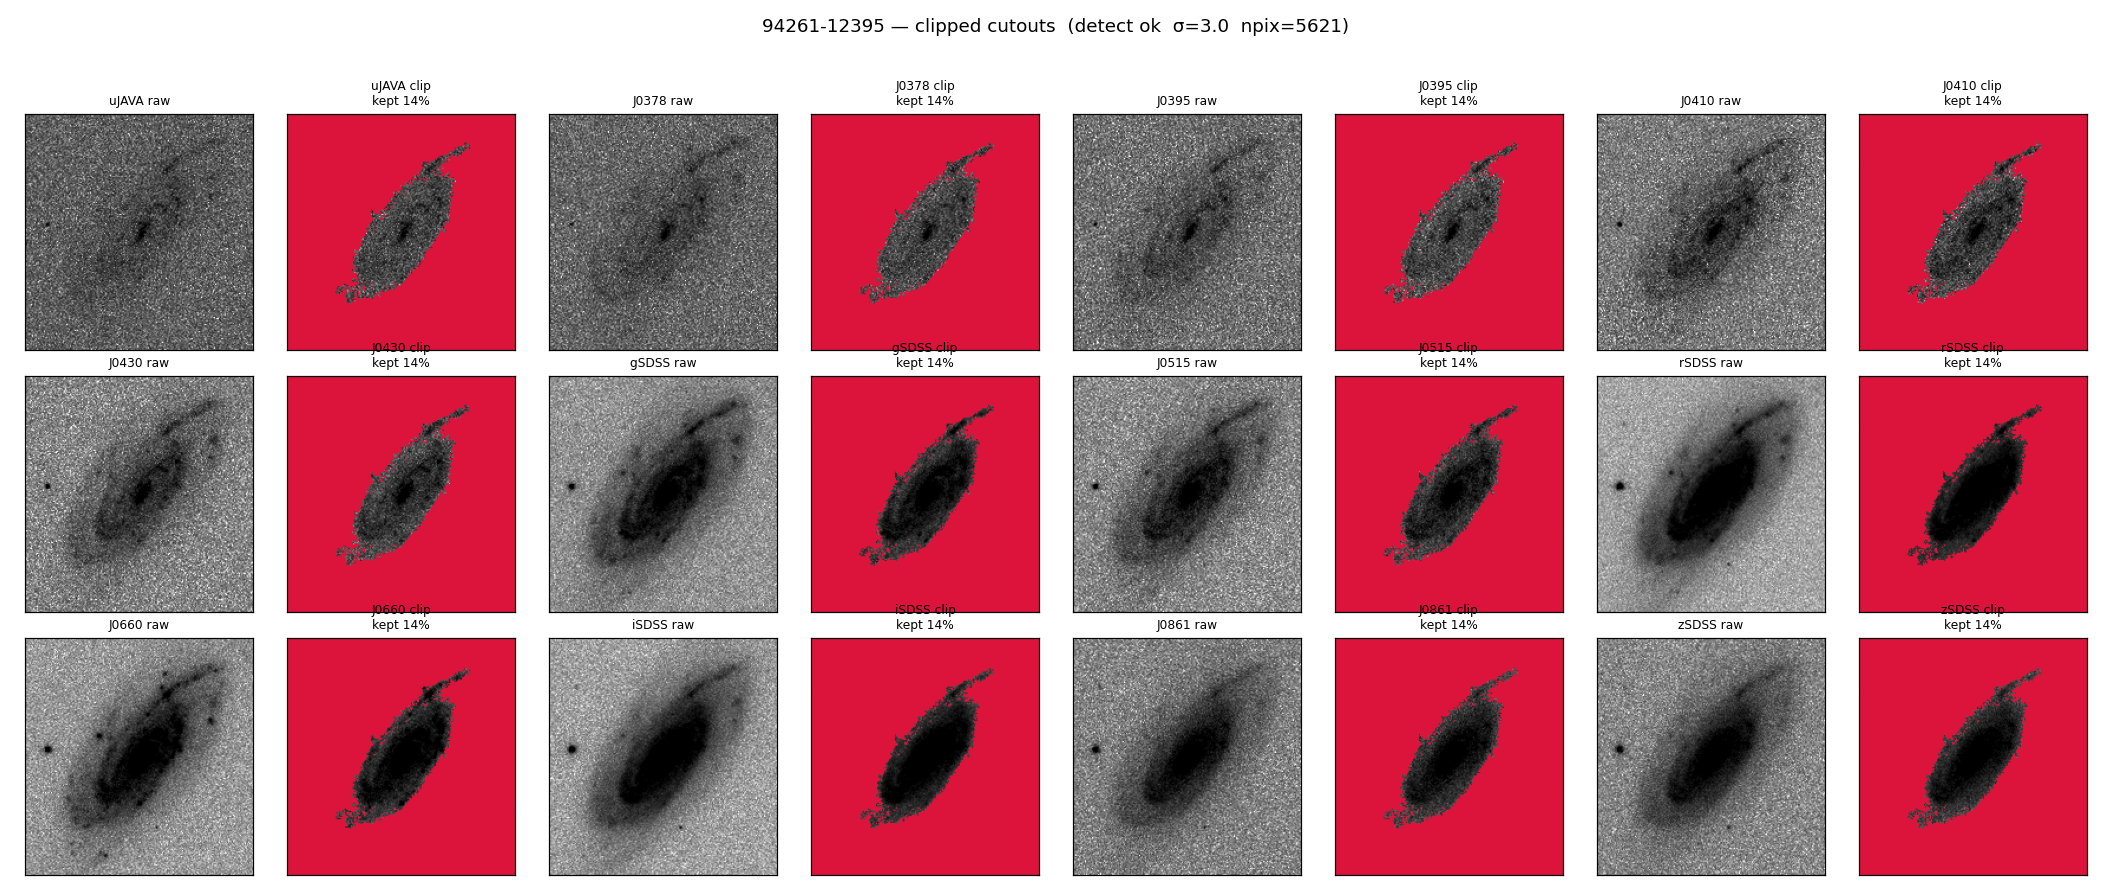

In [13]:
SINGLE_OBJECT_ID = "94261-12395"
out_png = DEMO_DIR / f"{SINGLE_OBJECT_ID}_clipped_summary.png"

status = summarize_object_clipped_cutouts(
    image_dir=images_root / SINGLE_OBJECT_ID,
    bands=list(ALL_BANDS),
    out_path=out_png,
)
print(f"summary status: {status}")

# Display the saved PNG inline.
from IPython.display import Image as IPyImage
IPyImage(filename=str(out_png))

## 10. Next steps

- Replace the synthetic galaxies with your real J-PLUS cutouts by pointing
  `images_root` at your data folder and dropping the `write_synthetic_object`
  calls.
- For batch runs the CLI is faster:
  ```bash
  palfitology make-cutouts        --detect-sigma 3.0 --apply-bands all
  palfitology fit-pa              --use-clipped-cutouts --workers 0
  palfitology summarize-cutouts   --limit 20
  ```
- Open follow-up: the NaN-fill step in Sections 4 and 6 is currently done in
  the notebook because `palfitology fit-pa --use-clipped-cutouts` passes
  NaN-bearing arrays straight to `photutils.isophote`, which often fails
  to converge.  A future release should fill NaN with the background mean
  inside the worker so the CLI workflow Just Works.